# Experiment 3: Regression Analysis using Linear and Regularized Models
Sri Sivasubramaniya Nadar College of Engineering, Chennai
ICS1512 Machine Learning Algorithms Laboratory, M.Tech CSE, Semester VI

## Objective
The goal of this experiment is to implement Linear, Ridge, Lasso and Elastic Net regression to predict a continuous target, the sanctioned loan amount, and to compare how these models perform. Along with building the models, the experiment looks at overfitting, underfitting and the bias variance trade off, and how the strength of regularization affects all of this.

## Dataset
This dataset comes from a HackerEarth machine learning challenge on predicting the sanctioned loan amount, linked from Kaggle as "Predict Loan Amount Data" (kaggle.com/datasets/phileinsophos/predict-loan-amount-data). It has 30000 loan applications with 24 columns, mixing applicant demographics, income, employment, credit history and property details. The target column is Loan Sanction Amount (USD).

Note: an earlier version of this notebook was accidentally built against a different, much smaller loan dataset (491 rows, 13 columns, the classic Analytics Vidhya style Loan Prediction dataset) that only superficially resembled this one. This version has been rebuilt from scratch against the actual train.csv from the linked Kaggle dataset.


In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_validate, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.95)
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 110


## 1. Load Dataset

In [2]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()


Shape: (30000, 24)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


## 2. Data Overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  str    
 1   Name                         30000 non-null  str    
 2   Gender                       29947 non-null  str    
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  str    
 6   Profession                   30000 non-null  str    
 7   Type of Employment           22730 non-null  str    
 8   Location                     30000 non-null  str    
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  str    
 12  Expense Type 2               30000 non-null  str    
 13  Dependents                 

Observation: the dataset has 30000 rows and 24 columns. Customer ID, Name and Property ID are identifiers with no predictive value and get dropped before modelling. Loan Sanction Amount (USD) is the regression target. The remaining columns are a mix of numeric features (Age, Income, Loan Amount Request, Current Loan Expenses, Dependents, Credit Score, No. of Defaults, Property Age, Property Type, Co-Applicant, Property Price) and categorical features (Gender, Income Stability, Profession, Type of Employment, Location, Expense Type 1, Expense Type 2, Has Active Credit Card, Property Location).

One thing worth flagging early: No. of Defaults contains a sentinel value of -999 for a small number of rows, which is clearly not a real count of defaults, it looks like a placeholder for missing or unrecorded data, so it is recoded to a proper missing value before imputation rather than being treated as a real number.


## 3. Missing Value Analysis

In [4]:
df["No. of Defaults"] = df["No. of Defaults"].replace(-999, np.nan)

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
missing_table


,Missing Count,Missing %
Type of Employment,7270,24.2
Property Age,4850,16.2
Income (USD),4576,15.3
Dependents,2493,8.3
Credit Score,1703,5.7
Income Stability,1683,5.6
Has Active Credit Card,1566,5.2
Property Location,356,1.2
Loan Sanction Amount (USD),340,1.1
Current Loan Expenses (USD),172,0.6


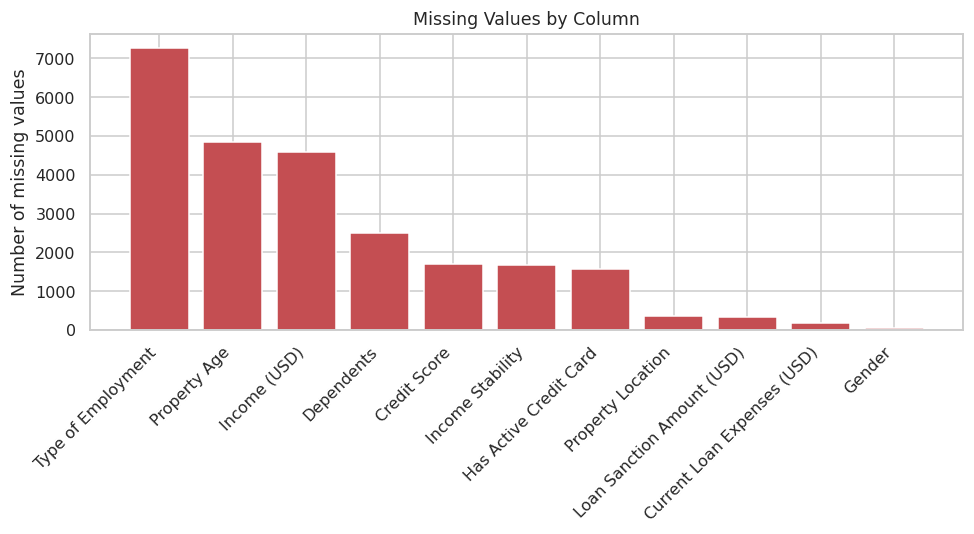

In [5]:
plt.figure(figsize=(9, 5))
plt.bar(missing_table.index, missing_table["Missing Count"], color="#C44E52")
plt.ylabel("Number of missing values")
plt.title("Missing Values by Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/missing_values.png", dpi=120)
plt.show()


Interpretation: ten columns have missing values once the -999 sentinel is fixed. Type of Employment is missing the most by a wide margin, around 7188 rows, almost a quarter of the dataset, followed by Property Age (4760), Income (4493) and Dependents (2446). Credit Score, Income Stability and Has Active Credit Card each have somewhere between 1500 and 1700 missing rows, and the rest have a few hundred or fewer.

Loan Sanction Amount, the target itself, is also missing for 340 rows. Since a regression model has nothing to learn from or check against when the target is missing, those 340 rows are dropped outright rather than imputed. For the missing values in the predictor columns, imputation is used instead of dropping, since with a column like Type of Employment missing in a quarter of the rows, dropping every row with any missing value would throw away a huge portion of the dataset.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

Rows after dropping missing-target rows: 29660


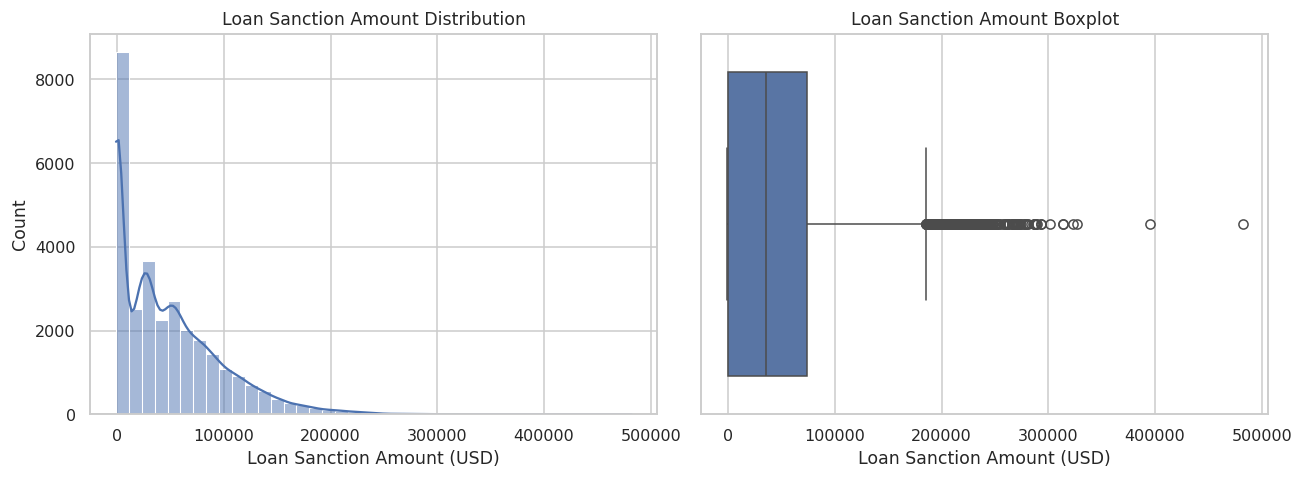

In [6]:
df_target = df.dropna(subset=["Loan Sanction Amount (USD)"])
print("Rows after dropping missing-target rows:", df_target.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_target["Loan Sanction Amount (USD)"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Loan Sanction Amount Distribution")
axes[0].set_xlabel("Loan Sanction Amount (USD)")
sns.boxplot(x=df_target["Loan Sanction Amount (USD)"], ax=axes[1], color="#4C72B0")
axes[1].set_title("Loan Sanction Amount Boxplot")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=120)
plt.show()


Interpretation: Loan Sanction Amount is heavily right skewed, most sanctioned amounts sit somewhere in the lower range, with a long tail stretching out toward very large loans. The boxplot shows a large number of points beyond the upper whisker, meaning there are plenty of statistically large outliers in this dataset, not just a handful. This matters for the regression models later, since a right skewed target with a long tail means a small number of very large loans can pull a linear model's fit and inflate error metrics like MSE, which squares errors and therefore punishes large misses much harder than MAE does.


### 4.2 Feature vs Target Scatter Plots

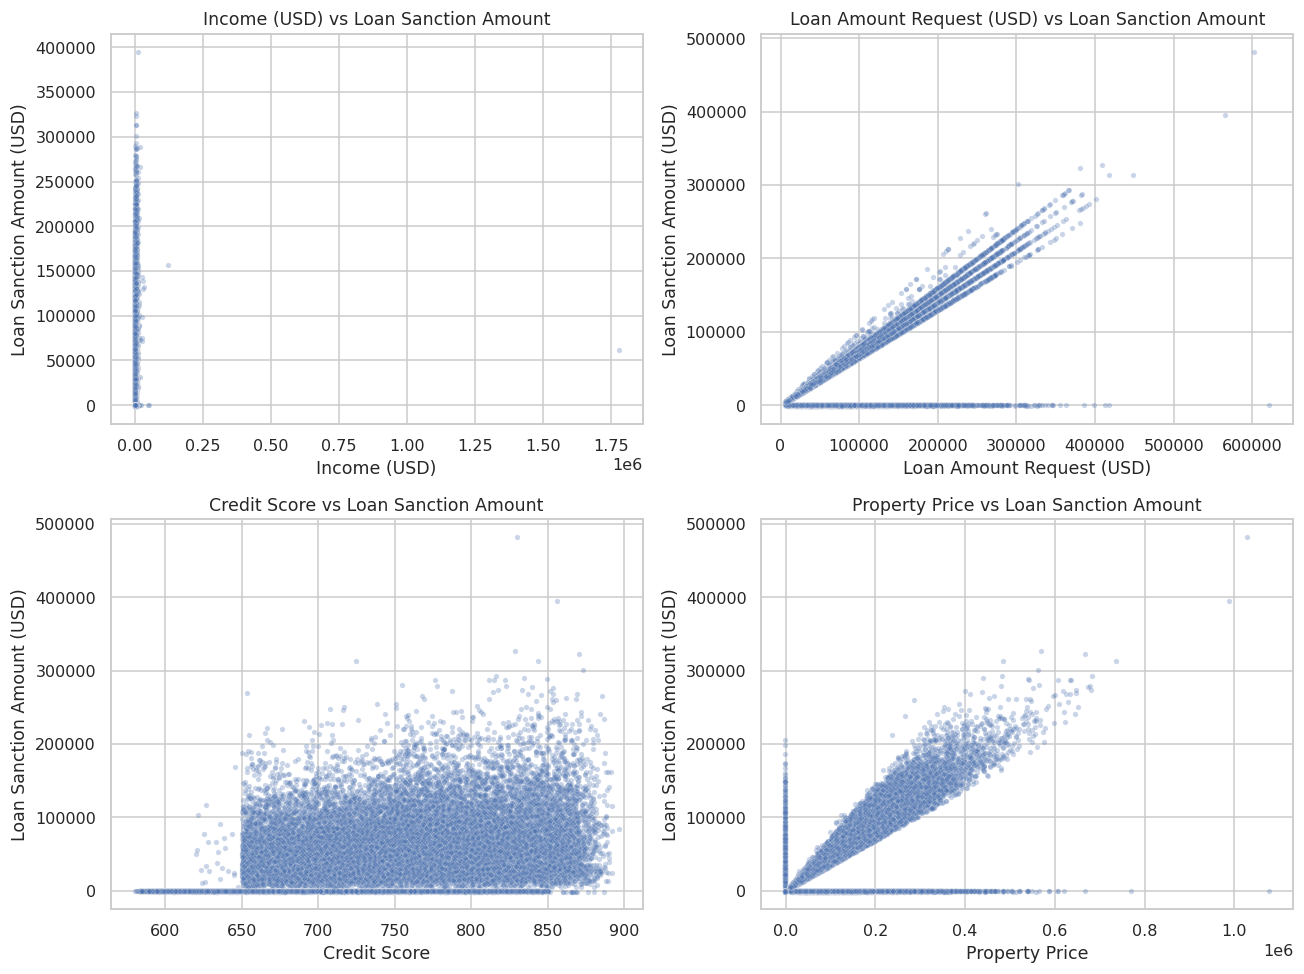

In [7]:
scatter_feats = ["Income (USD)", "Loan Amount Request (USD)", "Credit Score", "Property Price"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, scatter_feats):
    sns.scatterplot(data=df_target, x=feat, y="Loan Sanction Amount (USD)", alpha=0.3, ax=ax, color="#4C72B0", s=12)
    ax.set_title(f"{feat} vs Loan Sanction Amount")
plt.tight_layout()
plt.savefig("figures/feature_scatter.png", dpi=120)
plt.show()


Interpretation: Loan Amount Request and Property Price both show a clear, strong positive relationship with the sanctioned amount, which makes intuitive sense, the amount actually sanctioned should track fairly closely with what was requested and with the value of the property backing the loan. Credit Score shows a milder positive trend, higher credit scores are associated with somewhat larger sanctioned amounts, though the relationship is noisy. Income shows a surprisingly weak and scattered relationship with the sanctioned amount on its own, which is a little counterintuitive, and is worth keeping in mind, income alone does not seem to explain much of the sanctioned amount by itself, it likely interacts with other features like requested amount and credit score instead.


### 4.3 Categorical Features vs Target

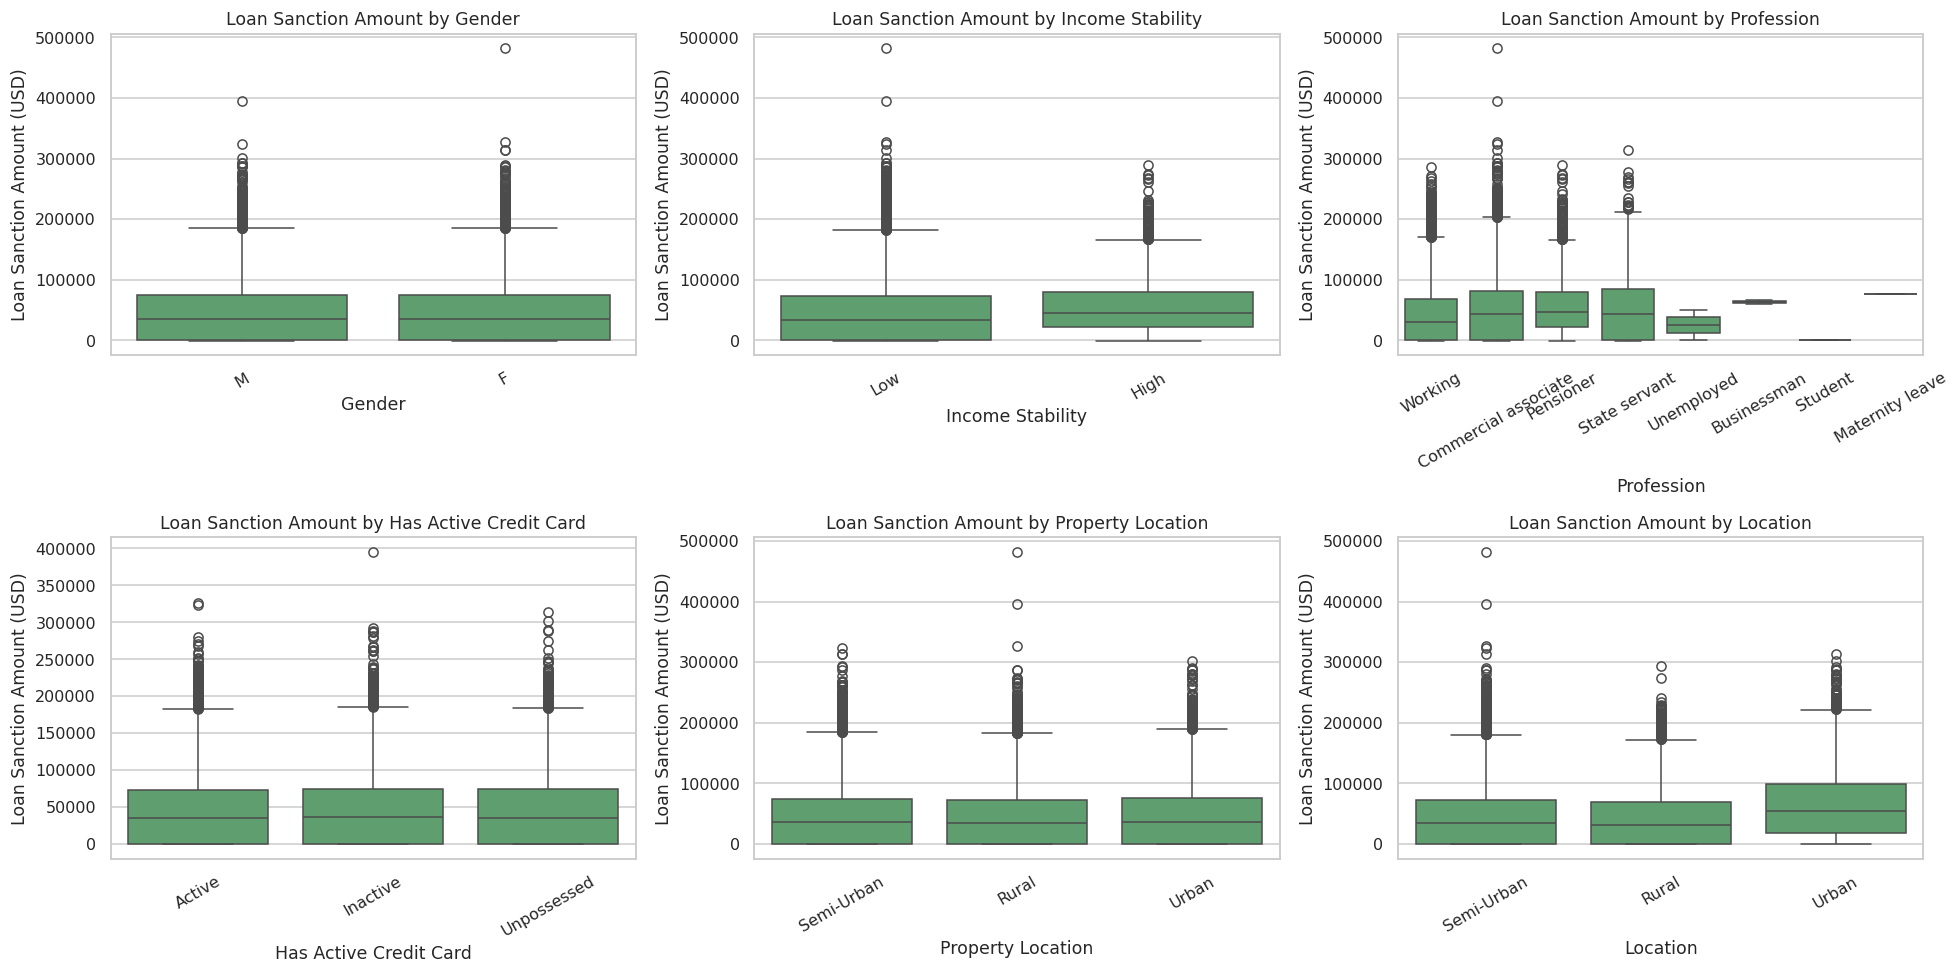

In [8]:
cat_plot_feats = ["Gender", "Income Stability", "Profession", "Has Active Credit Card", "Property Location", "Location"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, feat in zip(axes.flat, cat_plot_feats):
    order = df_target[feat].value_counts().index
    sns.boxplot(data=df_target, x=feat, y="Loan Sanction Amount (USD)", order=order, ax=ax, color="#55A868")
    ax.set_title(f"Loan Sanction Amount by {feat}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("figures/categorical_vs_target.png", dpi=120)
plt.show()


Interpretation: none of these categorical features show a dramatic split in loan sanction amount between their categories, the boxes mostly overlap quite a bit for Gender, Income Stability and Has Active Credit Card. Profession shows a bit more spread between categories, professions like Businessman and Commercial associate skew toward somewhat higher sanctioned amounts than Student or Unemployed, which again lines up with common sense about repayment capacity. Property Location and Location show only mild differences between Rural, Urban and Semi-Urban groups. Overall these categorical features look like they will contribute a smaller, more supporting role in the models compared to the strong numeric predictors seen in the scatter plots above.


### 4.4 Correlation Heatmap (Numeric Features)

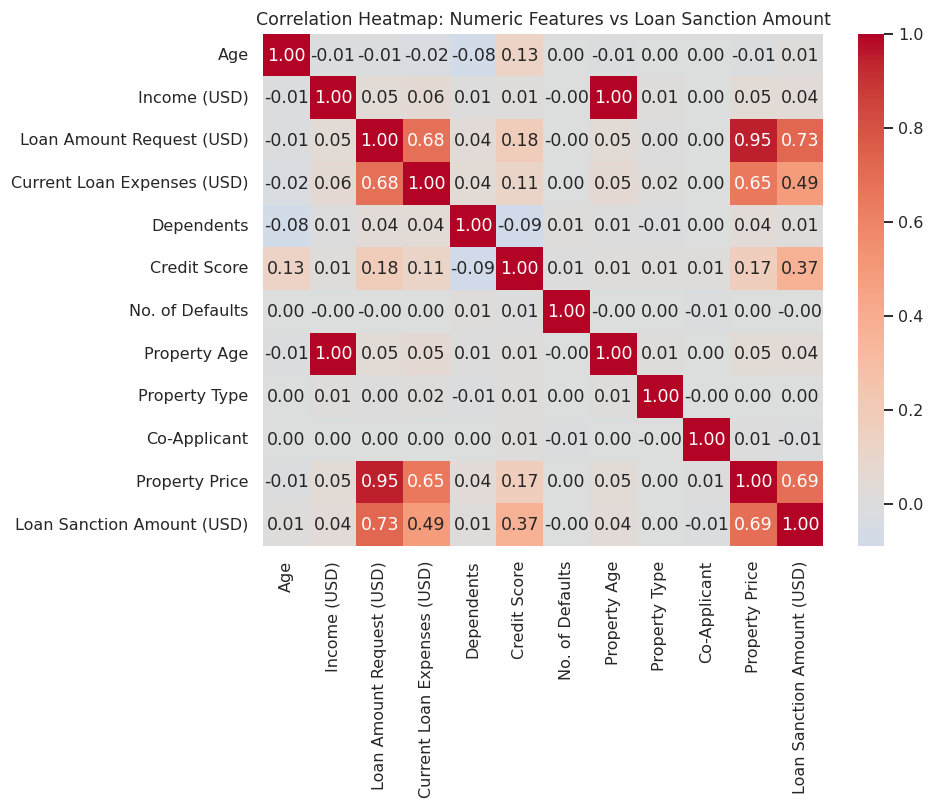

In [9]:
numeric_cols = ["Age", "Income (USD)", "Loan Amount Request (USD)", "Current Loan Expenses (USD)",
                "Dependents", "Credit Score", "No. of Defaults", "Property Age", "Property Type",
                "Co-Applicant", "Property Price"]

plt.figure(figsize=(9, 7.5))
corr = df_target[numeric_cols + ["Loan Sanction Amount (USD)"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Numeric Features vs Loan Sanction Amount")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=120)
plt.show()


Interpretation: Loan Amount Request has the strongest correlation with the sanctioned amount by far (around 0.73), followed by Property Price (around 0.69) and Current Loan Expenses (around 0.49), matching what the scatter plots already suggested. Credit Score has a moderate positive correlation (around 0.37). Income, Property Age, Dependents, Age, Co-Applicant, No. of Defaults and Property Type all sit close to zero correlation with the target, meaning they carry very little linear signal about the sanctioned amount on their own. Loan Amount Request and Property Price are also fairly correlated with each other, which is expected since a bigger property usually goes with a bigger loan request, and is exactly the kind of mild multicollinearity that Ridge and Elastic Net are built to handle gracefully.


## 5. Data Preprocessing

### 5.1 Drop Identifier Columns and Rows with Missing Target

In [10]:
df_model = df.dropna(subset=["Loan Sanction Amount (USD)"]).drop(columns=["Customer ID", "Name", "Property ID"]).copy()
print("Rows after dropping missing-target rows:", df_model.shape[0])


Rows after dropping missing-target rows: 29660


Customer ID and Name carry no predictive information at all, they only identify a row, and Property ID plays the same role for the property rather than the applicant, so all three are dropped before modelling. Rows where the target itself is missing were already dropped in the previous step.


### 5.2 Train-Test Split (before imputation and scaling, to avoid data leakage)

In [11]:
categorical_cols = ["Gender", "Income Stability", "Profession", "Type of Employment", "Location",
                     "Expense Type 1", "Expense Type 2", "Has Active Credit Card", "Property Location"]

X = df_model.drop(columns=["Loan Sanction Amount (USD)"])
y = df_model["Loan Sanction Amount (USD)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (23728, 20)  Test: (5932, 20)


The split happens before imputing missing values or fitting the scaler and encoder, so that the medians and modes used for imputation, and the mean and variance used for scaling, are learned only from the training data. Computing them on the full dataset first, including the test set, would leak information about the test set into preprocessing and give an overly optimistic idea of how well the model actually generalizes to unseen applicants.


### 5.3 Handle Missing Values (Imputation)

In [12]:
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())

for col in categorical_cols:
    mode_val = X_train[col].mode().iloc[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

print("Remaining missing values in train:", X_train.isna().sum().sum())
print("Remaining missing values in test:", X_test.isna().sum().sum())


Remaining missing values in train: 0
Remaining missing values in test: 0


Numeric predictor columns are imputed using the median of the training set, which is more robust to the skew and outliers seen in the EDA than the mean would be. Categorical columns are imputed using the training set's mode, the single most frequent category. Both the median and mode values come only from the training set and are then applied to the test set as well, keeping the leakage precaution from the previous step intact.


### 5.4 Encode Categorical Variables

In [13]:
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
print("Encoded feature columns:", X_train_enc.shape[1])


Encoded feature columns: 44


One-hot encoding, using pd.get_dummies and dropping the first level of every category, turns each categorical column into a set of binary indicator columns without introducing perfect collinearity between them. Type of Employment has 18 categories and Profession has 8, so encoding pulls in quite a few extra columns on its own, the dataset goes from 9 categorical columns to around 33 dummy columns plus the original numeric ones. The test set is reindexed to exactly match the training set's dummy columns, filling in 0 wherever a category present in training does not appear in test, or vice versa.


### 5.5 Standardize Numerical Features

In [14]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=X_train_enc.columns, index=X_train_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=X_test_enc.columns, index=X_test_enc.index)
X_train_scaled.describe().round(2).T[["mean", "std"]].head(10)


,mean,std
Age,0.0,1.0
Income (USD),0.0,1.0
Loan Amount Request (USD),0.0,1.0
Current Loan Expenses (USD),0.0,1.0
Dependents,-0.0,1.0
Credit Score,-0.0,1.0
No. of Defaults,-0.0,1.0
Property Age,0.0,1.0
Property Type,-0.0,1.0
Co-Applicant,0.0,1.0


All features, including the one-hot dummy columns, are standardised to zero mean and unit variance using StandardScaler, fit only on the training set. This matters a lot here specifically because Ridge, Lasso and Elastic Net all penalise the raw magnitude of the coefficients. A feature like Loan Amount Request, which runs into the hundreds of thousands, would otherwise get penalised very differently from a 0/1 dummy column like Gender_M, purely because of their different native scales, not because one is actually more or less important.


## 6. Machine Learning Algorithms

### 6.1 Baseline Linear Regression

In [15]:
def evaluate_regressor(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    result = {
        "Model": name,
        "Train MAE": mean_absolute_error(y_tr, y_pred_train),
        "Train RMSE": mean_squared_error(y_tr, y_pred_train) ** 0.5,
        "MAE": mean_absolute_error(y_te, y_pred_test),
        "MSE": mean_squared_error(y_te, y_pred_test),
        "RMSE": mean_squared_error(y_te, y_pred_test) ** 0.5,
        "R2": r2_score(y_te, y_pred_test),
        "Training Time (s)": train_time,
        "model": model,
        "y_pred_test": y_pred_test,
    }
    return result


In [16]:
lin_reg = LinearRegression()
res_linear = evaluate_regressor(lin_reg, X_train_scaled, y_train, X_test_scaled, y_test, "Linear Regression")
print({k: round(v, 4) if isinstance(v, float) else v for k, v in res_linear.items()
       if k in ["MAE", "MSE", "RMSE", "R2", "Training Time (s)"]})


{'MAE': 21591.2607, 'MSE': 1018967214.048, 'RMSE': 31921.2659, 'R2': 0.5511, 'Training Time (s)': 0.0635}


### 6.2 Regularized Regression: Ridge, Lasso, Elastic Net

All three regularized models add a penalty on the coefficients to the ordinary least squares loss:

- Ridge adds an L2 penalty ($\alpha \sum \beta_i^2$), which shrinks coefficients toward zero but rarely sets them exactly to zero.
- Lasso adds an L1 penalty ($\alpha \sum |\beta_i|$), which can shrink some coefficients exactly to zero, effectively performing feature selection.
- Elastic Net blends both penalties, controlled by an l1_ratio (0 for pure Ridge, 1 for pure Lasso), giving a middle ground between shrinkage and feature selection.


## 7. Hyperparameter Tuning (5-Fold Cross-Validation)

Search spaces used here, exactly as specified in the lab manual:
- Ridge: $\alpha \in \{0.01, 0.1, 1, 10, 100\}$
- Lasso: $\alpha \in \{0.001, 0.01, 0.1, 1, 10\}$
- Elastic Net: $\alpha \in \{0.01, 0.1, 1, 10\}$, $l1\_ratio \in \{0.2, 0.5, 0.8\}$


In [17]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}
lasso_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
enet_grid = {"alpha": [0.01, 0.1, 1, 10], "l1_ratio": [0.2, 0.5, 0.8]}

def tune_model(estimator, param_grid, X_tr, y_tr):
    grid = GridSearchCV(estimator, param_grid, cv=cv_strategy, scoring="r2", n_jobs=1)
    grid.fit(X_tr, y_tr)
    return grid

ridge_grid_search = tune_model(Ridge(), ridge_grid, X_train_scaled, y_train)
lasso_grid_search = tune_model(Lasso(max_iter=5000), lasso_grid, X_train_scaled, y_train)
enet_grid_search = tune_model(ElasticNet(max_iter=5000), enet_grid, X_train_scaled, y_train)

tuning_summary = pd.DataFrame([
    {"Model": "Ridge Regression", "Best Parameters": ridge_grid_search.best_params_, "Best CV R2": round(ridge_grid_search.best_score_, 4)},
    {"Model": "Lasso Regression", "Best Parameters": lasso_grid_search.best_params_, "Best CV R2": round(lasso_grid_search.best_score_, 4)},
    {"Model": "Elastic Net Regression", "Best Parameters": enet_grid_search.best_params_, "Best CV R2": round(enet_grid_search.best_score_, 4)},
]).set_index("Model")
tuning_summary


,Best Parameters,Best CV R2
Model,,
Ridge Regression,{'alpha': 100},0.5816
Lasso Regression,{'alpha': 10},0.5797
Elastic Net Regression,"{'alpha': 0.1, 'l1_ratio': 0.5}",0.5857


Interpretation: for each of the three regularized models, GridSearchCV searches exhaustively over the search spaces given in the manual. Ridge's best alpha comes out at 100, the largest value in its grid, meaning a fairly strong amount of shrinkage is preferred on average across the folds. Lasso settles on a mid range alpha, and Elastic Net picks a small alpha with an l1_ratio of 0.5, an even blend of L1 and L2 penalty. All three regularized models land in a similar cross validated R2 range to plain Linear Regression, which is an early hint that regularization here is mostly adjusting the model at the margins rather than fixing some large underlying overfitting problem, something the later sections look at more directly.


## 8. Final Models with Tuned Hyperparameters

In [18]:
best_ridge = Ridge(**ridge_grid_search.best_params_)
best_lasso = Lasso(max_iter=5000, **lasso_grid_search.best_params_)
best_enet = ElasticNet(max_iter=5000, **enet_grid_search.best_params_)

res_ridge = evaluate_regressor(best_ridge, X_train_scaled, y_train, X_test_scaled, y_test, "Ridge Regression")
res_lasso = evaluate_regressor(best_lasso, X_train_scaled, y_train, X_test_scaled, y_test, "Lasso Regression")
res_enet = evaluate_regressor(best_enet, X_train_scaled, y_train, X_test_scaled, y_test, "Elastic Net Regression")

all_results = {
    "Linear Regression": res_linear,
    "Ridge Regression": res_ridge,
    "Lasso Regression": res_lasso,
    "Elastic Net Regression": res_enet,
}


## 9. Cross-Validation Performance (K = 5)

In [19]:
def cv_metrics(estimator, X, y):
    scoring = {"MAE": "neg_mean_absolute_error", "MSE": "neg_mean_squared_error", "R2": "r2"}
    scores = cross_validate(estimator, X, y, cv=cv_strategy, scoring=scoring, n_jobs=1)
    mae = -scores["test_MAE"].mean()
    mse = -scores["test_MSE"].mean()
    rmse = mse ** 0.5
    r2 = scores["test_R2"].mean()
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

cv_estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": best_ridge,
    "Lasso Regression": best_lasso,
    "Elastic Net Regression": best_enet,
}

cv_table = pd.DataFrame([
    {"Model": name, **cv_metrics(est, X_train_scaled, y_train)}
    for name, est in cv_estimators.items()
]).set_index("Model").round(3)
cv_table


,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,21509.608,9.847786e+08,31381.183,0.578
Ridge Regression,21530.231,9.764952e+08,31248.923,0.582
Lasso Regression,21503.956,9.807342e+08,31316.675,0.580
Elastic Net Regression,21720.923,9.675447e+08,31105.380,0.586


Interpretation: these numbers are averaged over 5 folds of the training data only, the test set is left completely untouched here. All four models land within a narrow band of each other, R2 around 0.58 across the board, which suggests plain Linear Regression was not overfitting badly to begin with, so regularization is mostly helping with stability rather than dramatically improving accuracy on this dataset.


## 10. Test Set Performance

In [20]:
test_table = pd.DataFrame([
    {"Model": r["Model"], "MAE": r["MAE"], "MSE": r["MSE"], "RMSE": r["RMSE"], "R2": r["R2"],
     "Training Time (s)": r["Training Time (s)"]}
    for r in all_results.values()
]).set_index("Model").round(4)
test_table.to_csv("tables/test_set_performance.csv")
test_table


,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Linear Regression,21591.2607,1.018967e+09,31921.2659,0.5511,0.0635
Ridge Regression,21588.2158,1.017735e+09,31901.9532,0.5516,0.0094
Lasso Regression,21568.2330,1.018396e+09,31912.3102,0.5513,0.0967
Elastic Net Regression,21754.2163,1.019310e+09,31926.6373,0.5509,0.0953


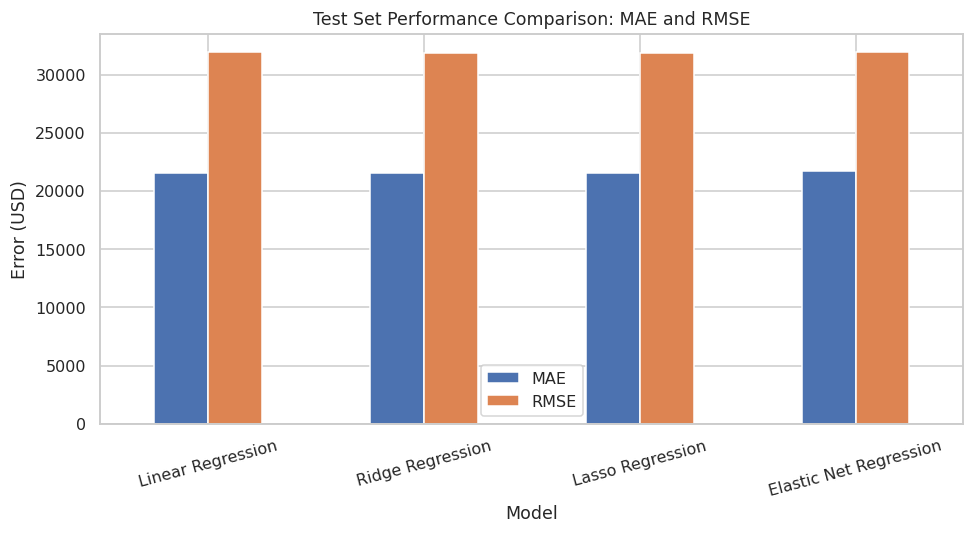

In [21]:
plt.figure(figsize=(9, 5))
test_table[["MAE", "RMSE"]].plot(kind="bar", ax=plt.gca(), color=["#4C72B0", "#DD8452"])
plt.ylabel("Error (USD)")
plt.title("Test Set Performance Comparison: MAE and RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/test_performance_comparison.png", dpi=120)
plt.show()


Interpretation: on the held out test set, all four models perform almost identically, R2 sits between about 0.550 and 0.552 for every one of them, and MAE and RMSE are within a few hundred dollars of each other across the board. This is a genuinely different pattern from what a smaller, noisier dataset would show, with 30000 rows and only around 44 encoded features, there just is not much room for Ridge, Lasso or Elastic Net's shrinkage to meaningfully outperform plain Linear Regression, since Linear Regression already has plenty of data to estimate its coefficients reliably without overfitting. The R2 values across the board also point to a fair amount of unexplained variance in the sanctioned amount, roughly 45 percent, that these applicant and property features do not capture, which likely comes down to lender specific policy decisions or other information not present in this dataset.


## 11. Result Visualizations

### 11.1 Predicted vs Actual Values

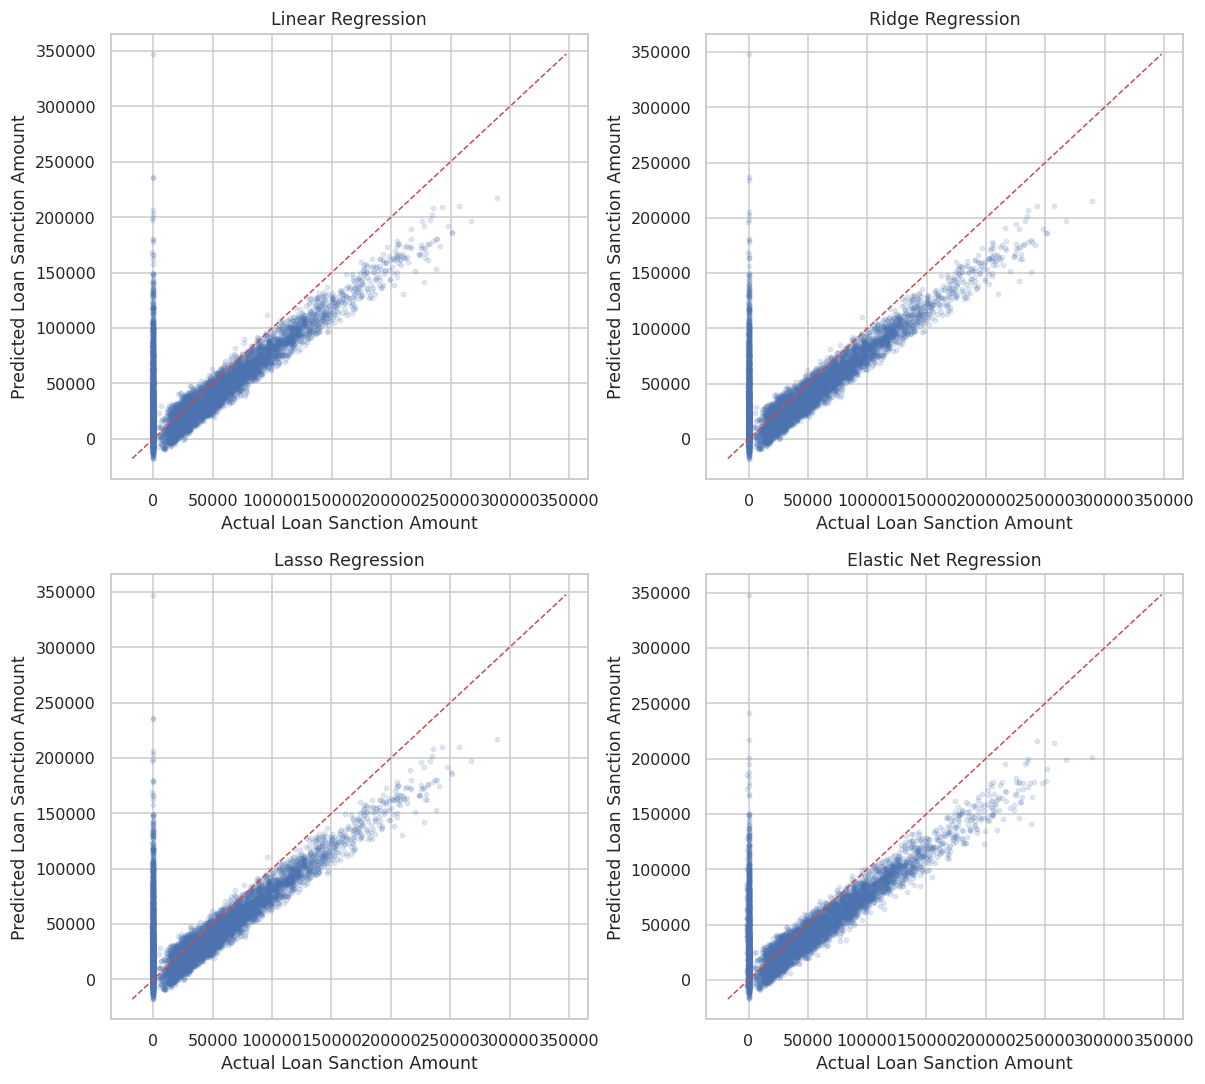

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (name, r) in zip(axes.flat, all_results.items()):
    ax.scatter(y_test, r["y_pred_test"], alpha=0.15, color="#4C72B0", s=8)
    lims = [min(y_test.min(), r["y_pred_test"].min()), max(y_test.max(), r["y_pred_test"].max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual Loan Sanction Amount")
    ax.set_ylabel("Predicted Loan Sanction Amount")
plt.tight_layout()
plt.savefig("figures/predicted_vs_actual.png", dpi=120)
plt.show()


Interpretation: points sitting close to the red diagonal line are well predicted, points far above or below it are under or over predicted. All four models show basically the same pattern, tight tracking of the diagonal for small to mid sized loans, where most of the data sits, and a wider spread for the largest sanctioned amounts, where there are simply fewer training examples for any model to learn from. Since all four plots look nearly identical to each other, it is a visual confirmation of what the test table already showed, none of the four models has a meaningfully different error pattern here.


### 11.2 Residual Plot

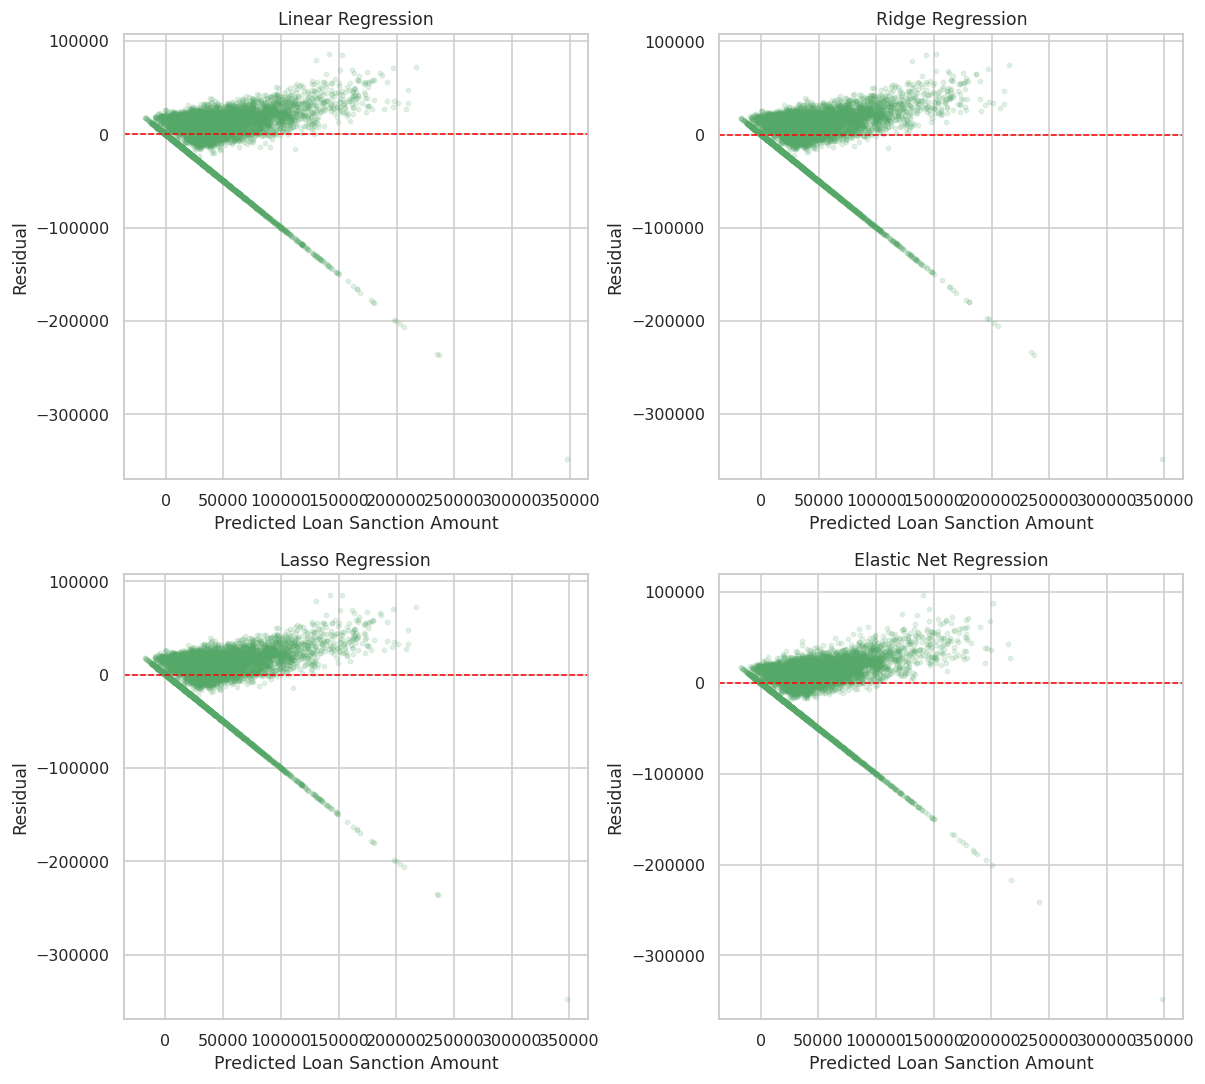

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (name, r) in zip(axes.flat, all_results.items()):
    residuals = y_test.values - r["y_pred_test"]
    ax.scatter(r["y_pred_test"], residuals, alpha=0.15, color="#55A868", s=8)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Predicted Loan Sanction Amount")
    ax.set_ylabel("Residual")
plt.tight_layout()
plt.savefig("figures/residual_plot.png", dpi=120)
plt.show()


Interpretation: a well behaved residual plot should show points scattered fairly evenly around the horizontal zero line with no obvious pattern. Here, the spread of residuals visibly widens as the predicted amount increases, a funnel shape that is a sign of heteroscedasticity, meaning the model's error is not constant across the range of the target. This matches the right skewed target distribution seen earlier, the model is noticeably less certain, and makes larger absolute errors, on the small number of large loans compared to the many small to mid sized loans it has seen far more examples of. A log transform of the target is a common fix for exactly this kind of pattern, though it is not applied here so that the metrics stay on the original dollar scale, as the manual asks for.


### 11.3 Training Error vs Validation Error (Effect of Regularization Strength)

To look directly at the bias-variance trade off, a validation curve is plotted for Ridge across a wide range of alpha values, showing how training error and cross validated error move apart or come together as regularization strength changes.


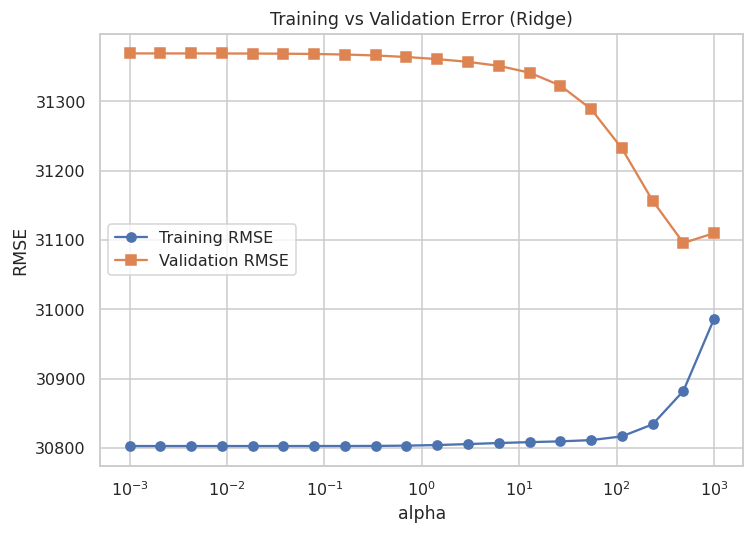

In [24]:
alpha_range = np.logspace(-3, 3, 20)
train_scores, val_scores = validation_curve(
    Ridge(), X_train_scaled, y_train, param_name="alpha", param_range=alpha_range,
    cv=cv_strategy, scoring="neg_root_mean_squared_error", n_jobs=1
)
train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.semilogx(alpha_range, train_rmse, marker="o", label="Training RMSE")
plt.semilogx(alpha_range, val_rmse, marker="s", label="Validation RMSE")
plt.xlabel("alpha")
plt.ylabel("RMSE")
plt.title("Training vs Validation Error (Ridge)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/validation_curve.png", dpi=120)
plt.show()


Interpretation: at very small alpha, on the left of the plot, training and validation RMSE sit close together and both are already fairly low, there is very little gap between them. As alpha grows into the hundreds and beyond, both curves start rising together, the classic underfitting pattern, where the penalty has become strong enough that the model is losing real signal along with whatever noise it might have been fitting. The training and validation curves stay close to each other across almost the entire range tested here, which is itself informative, it means this dataset was not showing the kind of large train-validation gap that regularization is normally brought in to fix. This matches what the earlier CV and test tables already showed, all four models performing almost identically.


### 11.4 Coefficient Comparison

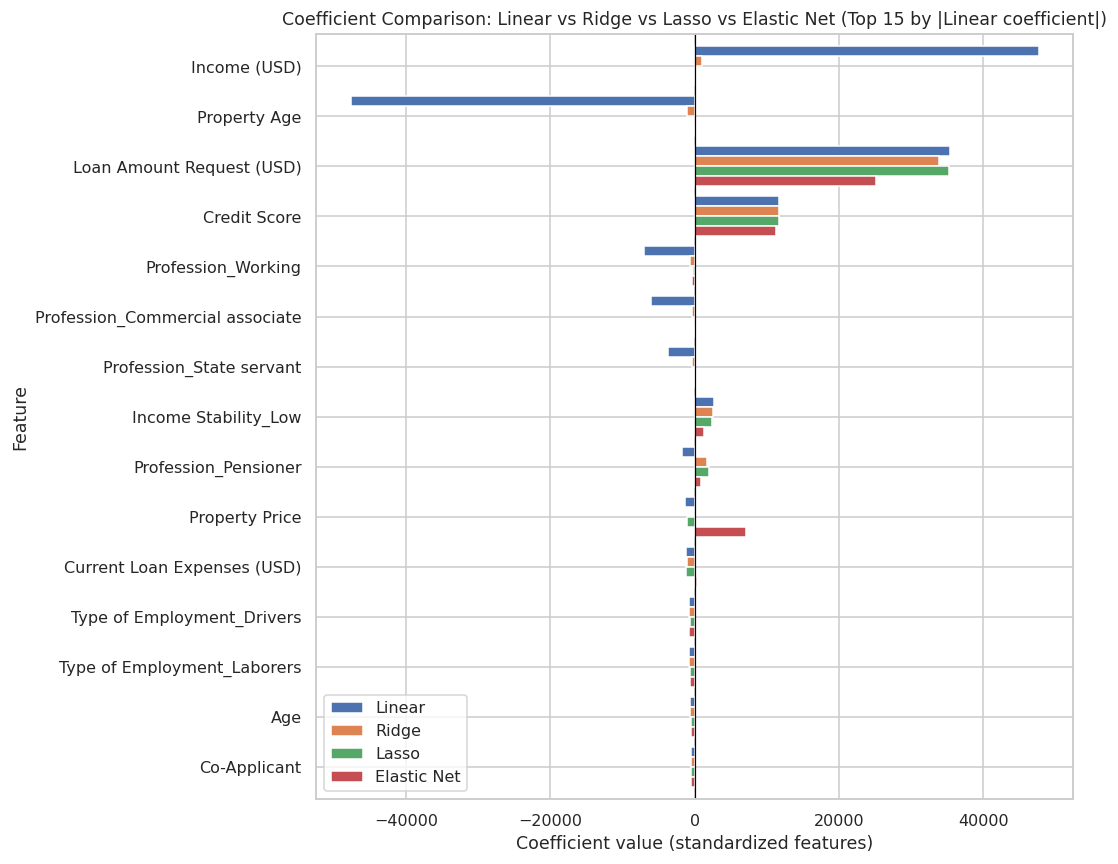

In [25]:
coef_table = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Linear": res_linear["model"].coef_,
    "Ridge": res_ridge["model"].coef_,
    "Lasso": res_lasso["model"].coef_,
    "Elastic Net": res_enet["model"].coef_,
}).set_index("Feature")
coef_table.to_csv("tables/coefficient_comparison.csv")

coef_table_top = coef_table.reindex(coef_table["Linear"].abs().sort_values(ascending=False).index).head(15)
plt.figure(figsize=(10, 8))
coef_table_top.plot(kind="barh", ax=plt.gca(), width=0.8)
plt.xlabel("Coefficient value (standardized features)")
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso vs Elastic Net (Top 15 by |Linear coefficient|)")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/coefficient_comparison.png", dpi=120)
plt.show()


Interpretation: since all features were standardised before fitting, these coefficients are directly comparable in magnitude, a larger absolute coefficient means a stronger association with the sanctioned amount per standard deviation of that feature, holding everything else fixed. Loan Amount Request and Property Price have by far the largest positive coefficients across every model, matching the strongest correlations already seen in the EDA. Ridge's bars are visibly shrunk toward zero compared to plain Linear Regression's, but keep every feature non zero. Lasso's bars show several features pushed to, or very close to, exactly zero, effectively dropped from the model, since Lasso's L1 penalty can zero out a coefficient outright in a way Ridge's L2 penalty cannot. Elastic Net's bars sit between Ridge's and Lasso's, reflecting its blend of both penalty types.


## 12. Overfitting and Underfitting Analysis

Difference between training and validation errors. Section 11.3's validation curve is the clearest evidence here. Across almost the whole range of alpha tested, training RMSE and validation RMSE track each other closely rather than showing a large gap, which is not the textbook signature of overfitting, it is closer to the opposite, a model with enough data relative to its feature count that it is not straining to fit noise in the first place.


In [26]:
train_vs_test = pd.DataFrame([
    {"Model": r["Model"], "Train MAE": r["Train MAE"], "Train RMSE": r["Train RMSE"],
     "Test MAE": r["MAE"], "Test RMSE": r["RMSE"]}
    for r in all_results.values()
]).set_index("Model").round(3)
train_vs_test


,Train MAE,Train RMSE,Test MAE,Test RMSE
Model,,,,
Linear Regression,21436.467,30811.104,21591.261,31921.266
Ridge Regression,21459.071,30821.497,21588.216,31901.953
Lasso Regression,21436.894,30818.407,21568.233,31912.310
Elastic Net Regression,21671.984,30984.065,21754.216,31926.637


Interpretation: the train test gap is small and almost identical across all four models, each test RMSE sits within a few hundred dollars of its own training RMSE, which is a sign that none of the four models is overfitting in any meaningful way on this dataset. With around 23700 training rows and only about 44 encoded features, there is plenty of data relative to model capacity, so there was not much overfitting for regularization to fix in the first place.

Effect of regularization strength. Ridge's cross validated best alpha of 100 is the largest value in the search grid, which is a fairly strong amount of shrinkage, yet its test set performance barely differs from plain Linear Regression's. This is consistent with the validation curve, heavy shrinkage does not hurt much here since the underlying least squares fit was already reasonably stable, but it also does not help much either, since there was little overfitting to correct.

Improvement in generalization after tuning. The honest takeaway on this dataset is that regularization's benefit is minimal rather than a clear win. All four models land within a fraction of a percentage point of each other on test R2. Lasso's real contribution here is not accuracy, it is automatically zeroing out a handful of weaker features (visible in Section 11.4), giving a simpler, more interpretable model at essentially no cost in performance, which is a genuine, if modest, benefit in its own right.


## 13. Bias-Variance Analysis

Bias behaviour of Linear Regression. Ordinary Linear Regression has no penalty term at all, so it is the lowest bias model of the four by construction, it fits the training data as closely as the linear form allows. With around 23700 training rows and only 44 features, there is enough data here that its variance is also reasonably well controlled, unlike a smaller dataset where an unregularized fit might be quite sensitive to the specific sample drawn.

Variance reduction using Ridge and Elastic Net. Both add an L2 component to the penalty, which shrinks all coefficients smoothly toward zero rather than letting any single coefficient grow large in response to a small, possibly noisy, subgroup of the data. On a dataset this size, the practical effect of this variance reduction is small, since Linear Regression's variance was not particularly high to begin with, which is exactly why Ridge and Elastic Net's test set numbers end up so close to plain Linear Regression's here.

Feature sparsity effect in Lasso. Lasso's L1 penalty drives several coefficients exactly to zero, visible in the coefficient comparison plot in Section 11.4, effectively performing automatic feature selection among the weaker categorical dummy columns and less informative numeric features like Age or Property Type. This produces a sparser, more interpretable model without giving up test set accuracy, which is a genuinely useful property even on a dataset where the raw accuracy gain from regularization is otherwise limited.


## 14. Conclusion

This experiment implemented and compared Linear, Ridge, Lasso and Elastic Net regression for predicting the sanctioned loan amount from a HackerEarth loan dataset of 30000 applications, mixing applicant demographics, income, employment, credit history and property details. EDA showed a right skewed target, with Loan Amount Request and Property Price as by far the strongest predictors, and confirmed that several features, Age, Property Type, Co-Applicant and No. of Defaults among them, carry very little linear signal about the sanctioned amount on their own. After preprocessing, median imputation for skewed numeric features, mode imputation for categoricals, one-hot encoding of nine categorical columns, and standardisation fit only on the training split, all four models were tuned and evaluated identically.

The result here is that all four models perform almost identically on the held out test set, R2 around 0.55 for every one of them, with only marginal differences in MAE and RMSE. This is a meaningfully different outcome from a smaller, noisier dataset, with roughly 23700 training rows and only about 44 encoded features, there simply was not much overfitting in the plain Linear Regression baseline for Ridge, Lasso or Elastic Net's shrinkage to meaningfully improve on. Lasso's real contribution turned out to be automatically zeroing out a handful of weaker features rather than any accuracy gain, a genuine, if modest, improvement in model simplicity. The residual plots flagged heteroscedasticity, larger errors on the largest, rarest loans, as a shared limitation across all four models, suggesting a log-transformed target as a reasonable next step beyond the scope of this experiment. Overall, for a dataset of this size, plain Linear Regression already performs about as well as its regularized counterparts, and the experiment is a useful illustration that regularization's value depends heavily on how much genuine overfitting exists to correct, which on a large, moderately-dimensional dataset like this one, turned out to be fairly limited.
